# The British Grand Prix - 2026 🇬🇧 | The Sprint Qualifying

- This notebook is full pre-race technical debrief of the Sprint Qualifying Session at the British Grand Prix, 2026.

## Necessary Imports

In [1]:
# FastF1 Deps
import fastf1
from fastf1.core import Laps

# Data Deps
import pandas as pd

# Visualisation Deps
import matplotlib.pyplot as plt

# Core Deps
from pathlib import Path
import sys
sys.path.append(str(Path("../../")))

# Source Deps
from mark_1 import DataLoader, DataPipeline, DataVisualisation
from mark_1.utils import display_sector_stat

## Notebook-Level Setup and Configurations

In [2]:
# Accessing the Current Working Directory for Absolute Root Path
REPO_ROOT_PATH = Path.cwd().parent.parent.parent

# Pathlib Path Objects for the Notebook
F1_PATH = REPO_ROOT_PATH / "F1"
CACHE_PATH = F1_PATH / "cache"
CACHE_PATH.mkdir(exist_ok=True)

# Path to store the final quali frame
f1_data_path = F1_PATH / "data"
f1_data_path.mkdir(exist_ok=True)

# Adding the source scripts into the Python Execution Path
if F1_PATH not in sys.path:
    sys.path.append(str(F1_PATH))

## Loading the Event

In [3]:
# Defaulting the Requests for Caching to a Predefined path
# fastf1.Cache.clear_cache(cache_dir=str(CACHE_PATH))
fastf1.Cache.enable_cache(cache_dir=str(CACHE_PATH))

# Enabling Offline Mode
fastf1.Cache.offline_mode(enabled=True)

# The GP Event
britain_2026 = fastf1.get_event(
    year=2026,
    gp="britain"
)
print(britain_2026)

events      WARNING 	Correcting user input 'britain' to 'British Grand Prix'


RoundNumber                                                  9
Country                                         United Kingdom
Location                                           Silverstone
OfficialEventName    FORMULA 1 PIRELLI BRITISH GRAND PRIX 2026
EventDate                                  2026-07-05 00:00:00
EventName                                   British Grand Prix
EventFormat                                  sprint_qualifying
Session1                                            Practice 1
Session1Date                         2026-07-03 12:30:00+01:00
Session1DateUtc                            2026-07-03 11:30:00
Session2                                     Sprint Qualifying
Session2Date                         2026-07-03 16:30:00+01:00
Session2DateUtc                            2026-07-03 15:30:00
Session3                                                Sprint
Session3Date                         2026-07-04 12:00:00+01:00
Session3DateUtc                            2026-07-04 1

In [4]:
britain_2026 = DataLoader(race_event=britain_2026)
gp_weekend = britain_2026.load_data(is_sprint=True)

core           INFO 	Loading data for British Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '16', '44', '63', '6', '1', '3', '81', '41', '30', '5', '10', '27', '87', '55', '23', '31', '77', '43', '11', '18', '14']
core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	Usi

In [5]:
# Decompiling the Session Data
quali = gp_weekend.sprint_quali_session
race = gp_weekend.sprint_session

## Data Engineering

<img src="../../../assets/circuit_maps/silverstone_map.avif">

In [6]:
# Instantiating the DataPipeline
data_pipe = DataPipeline(circuit="britain")

# Full Laps Frame
assert quali, "Qualifying was not loaded"
quali_laps_full = quali.laps

# Drop columns
drop_cols = [
    "Sector1SessionTime", "Sector2SessionTime", "Sector3SessionTime", 
    "DeletedReason", "FastF1Generated", "IsAccurate", "Time"
]

# Filtered Laps
_, _, q3 = quali_laps_full.split_qualifying_sessions()
assert isinstance(q3, Laps), "Q3 Laps was None"
filtered_quali_laps = q3.drop(drop_cols, axis=1)

# Rounding down to the laps of the top runners
assert race, "Race was not loaded"
top_5_drivers = race.results.iloc[:5]["Abbreviation"].to_list()

# Retrieving the best laps
fastest_quali_laps = data_pipe.get_filtered_quali_laps(
    laps_frame=filtered_quali_laps,
    drivers=top_5_drivers
)

fastest_quali_laps.head()

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST
0,ANT,0 days 00:00:28.094000,0 days 00:00:35.750000,0 days 00:00:24.543000,0 days 00:01:28.387000,302.0,268.0,249.0,301.0
1,HAM,0 days 00:00:28.113000,0 days 00:00:35.706000,0 days 00:00:24.557000,0 days 00:01:28.376000,300.0,267.0,241.0,298.0
2,LEC,0 days 00:00:28.159000,0 days 00:00:35.841000,0 days 00:00:24.703000,0 days 00:01:28.703000,300.0,267.0,243.0,300.0
3,NOR,0 days 00:00:28.291000,0 days 00:00:35.937000,0 days 00:00:24.512000,0 days 00:01:28.740000,299.0,270.0,244.0,304.0
4,RUS,0 days 00:00:28.301000,0 days 00:00:35.854000,0 days 00:00:24.578000,0 days 00:01:28.733000,295.0,267.0,247.0,299.0


In [7]:
# Transforming all the timedelta objects
get_seconds = pd.Timedelta.total_seconds

fastest_quali_laps["LapTime"] = fastest_quali_laps.apply(
    lambda x: get_seconds(x["LapTime"]),
    axis=1
)
fastest_quali_laps["Sector1Time"] = fastest_quali_laps.apply(
    lambda x: get_seconds(x["Sector1Time"]),
    axis=1
)
fastest_quali_laps["Sector2Time"] = fastest_quali_laps.apply(
    lambda x: get_seconds(x["Sector2Time"]),
    axis=1
)
fastest_quali_laps["Sector3Time"] = fastest_quali_laps.apply(
    lambda x: get_seconds(x["Sector3Time"]),
    axis=1
)

fastest_quali_laps.head()

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST
0,ANT,28.094,35.750,24.543,88.387,302.0,268.0,249.0,301.0
1,HAM,28.113,35.706,24.557,88.376,300.0,267.0,241.0,298.0
2,LEC,28.159,35.841,24.703,88.703,300.0,267.0,243.0,300.0
3,NOR,28.291,35.937,24.512,88.740,299.0,270.0,244.0,304.0
4,RUS,28.301,35.854,24.578,88.733,295.0,267.0,247.0,299.0


### Best Theoritical Time

In [8]:
# Sector Enum
sectors = ["Sector1Time", "Sector2Time", "Sector3Time"]

# The Theoritical Best Time
best_times = {}

print("Theoritical Best Sectors:\n")
for idx, key in enumerate(sectors):
    fastest_sector = fastest_quali_laps.loc[fastest_quali_laps[key].idxmin()]
    best_times[key] = fastest_sector[key]
    
    assert isinstance(fastest_sector, pd.Series), f"Fastest sector was not found for {key}"
    display_sector_stat(fastest_sector, sector=idx+1)

fastest_laptime = (
    best_times["Sector1Time"] 
    + best_times["Sector2Time"] 
    + best_times["Sector3Time"]
)
print(f"Theoretical Best Time: {fastest_laptime}")

Theoritical Best Sectors:

Sector - 1
Driver: ANT
Sector Time: 28.094
Speed I1: 302.0
Longest Straight Speed: 301.0

Sector - 2
Driver: HAM
Sector Time: 35.706
Speed I2: 267.0
Longest Straight Speed: 298.0

Sector - 3
Driver: NOR
Sector Time: 24.512
Speed I3: 244.0
Longest Straight Speed: 304.0

Theoretical Best Time: 88.31200000000001


### Aero Efficiency Index
A comparison of the average speed (weighted by sector time) carried by each of the drivers and teams through the lap. The Silverstone Circuit (one of my favourite tracks ✨), has always been a High-Speed, High-Energy track layout that can be broken as follows:
1. `Front-Axle | High Speed & Medium Downforce` **Sector - 1**: Generically, due to the high-speed nature of the circuit the main tradeoff in setup is always the decision of Downforce (high-speed corners) and Drag (medium-long straights). However, the first sector, is argually one of the highest energy sections on the circuit through turns 1-3 (Abbey, Farm and Village) followed by the Wellington Straight. Thus, to gain time, a car needs to have sufficienty front-end at high-speed.
2. `Balanced | Downforce - Drag Tradeoff` **Sector - 2**: Requires sufficient traction for turns 6-7 😂 (Brooklands and Luffield) followed by another high-speed section through turns 9-14 (Copse, Maggotts, Becketts and Chapel). However, with the current generation of cars, this section is nowhere near as fast as it used to be. Hence a balanced setup is necessary to provide traction while harvesting and carrying the maximum speed possible through the corners.l
3. `Rear-Axle | Drag & Traction` **Sector - 3**: At this, the tyres loose most of their grip and have two long straights before the end of the lap with Stowe (the only real high-energy corner). Thus, a setup with the best traction delivery will perform grip is essential to gain straight line speed while deployment is a bonus.

In [9]:
# Sector - 1
fastest_quali_laps.loc[:, "FrontAEI"] = fastest_quali_laps.apply(
    lambda x: data_pipe._calc_aero_efficiency(
        v_sector=x["SpeedI1"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector1Time"],
        purple_sector_time=fastest_quali_laps["Sector1Time"].min()
    ),
    axis=1
)

# Sector - 2
fastest_quali_laps.loc[:, "BalancedAEI"] = fastest_quali_laps.apply(
    lambda x: data_pipe._calc_aero_efficiency(
        v_sector=x["SpeedI2"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector2Time"],
        purple_sector_time=fastest_quali_laps["Sector2Time"].min()
    ),
    axis=1
)

# Sector - 3
fastest_quali_laps.loc[:, "RearAEI"] = fastest_quali_laps.apply(
    lambda x: data_pipe._calc_aero_efficiency(
        v_sector=x["SpeedFL"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector3Time"],
        purple_sector_time=fastest_quali_laps["Sector3Time"].min()
    ),
    axis=1
)

fastest_quali_laps

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,FrontAEI,BalancedAEI,RearAEI
0,ANT,28.094,35.750,24.543,88.387,302.0,268.0,249.0,301.0,0.278701,0.247019,0.229499
1,HAM,28.113,35.706,24.557,88.376,300.0,267.0,241.0,298.0,0.279453,0.248881,0.224234
2,LEC,28.159,35.841,24.703,88.703,300.0,267.0,243.0,300.0,0.277137,0.246291,0.223260
3,NOR,28.291,35.937,24.512,88.740,299.0,270.0,244.0,304.0,0.271307,0.245125,0.222953
4,RUS,28.301,35.854,24.578,88.733,295.0,267.0,247.0,299.0,0.272057,0.247025,0.228852


### Power Unit Performance

In [10]:
# ============================ Adding the Kinetic Energies ============================
# Sector - 1
fastest_quali_laps.loc[:, "KineticEnergyS1_KJ"] = fastest_quali_laps.apply(
    lambda x: data_pipe._calc_delta_kinetic_energy(
        v1=x["SpeedI1"], 
        v2=x["SpeedST"]
    ),
    axis=1
)

# Sector - 2
fastest_quali_laps.loc[:, "KineticEnergyS2_KJ"] = fastest_quali_laps.apply(
    lambda x: data_pipe._calc_delta_kinetic_energy(
        v1=x["SpeedI2"], 
        v2=x["SpeedST"]
    ),
    axis=1
)

# Sector - 3
fastest_quali_laps.loc[:, "KineticEnergyS3_KJ"] = fastest_quali_laps.apply(
    lambda x: data_pipe._calc_delta_kinetic_energy(
        v1=x["SpeedFL"], 
        v2=x["SpeedST"]
    ),
    axis=1
)

# ============================ Adding the Power in KW ============================
# Sector - 1
fastest_quali_laps["PowerS1_KW"] = (
    fastest_quali_laps["KineticEnergyS1_KJ"] / 
    fastest_quali_laps["Sector1Time"]
)

# Sector - 2
fastest_quali_laps["PowerS2_KW"] = (
    fastest_quali_laps["KineticEnergyS2_KJ"] / 
    fastest_quali_laps["Sector2Time"]
)

# Sector - 3
fastest_quali_laps["PowerS3_KW"] = (
    fastest_quali_laps["KineticEnergyS3_KJ"] / 
    fastest_quali_laps["Sector3Time"]
)

# ERS Clipping
fastest_quali_laps["ERS_Clipping"] = fastest_quali_laps["SpeedST"] / fastest_quali_laps["SpeedI2"]

# Adding the Acceleration Time
fastest_quali_laps.loc[:, "AccelerationTime"] = fastest_quali_laps.apply(
    lambda x: data_pipe.get_delta_acceleration_time(
        v1=x["SpeedI2"], 
        v2=x["SpeedST"]
    ),
    axis=1
)

fastest_quali_laps

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,FrontAEI,BalancedAEI,RearAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW,ERS_Clipping,AccelerationTime
0,ANT,28.094,35.750,24.543,88.387,302.0,268.0,249.0,301.0,0.278701,0.247019,0.229499,-17.959722,559.253241,851.820988,-0.639273,15.643447,34.707289,1.123134,8.224956
1,HAM,28.113,35.706,24.557,88.376,300.0,267.0,241.0,298.0,0.279453,0.248881,0.224234,-35.621605,521.665895,915.052315,-1.267087,14.610035,37.262382,1.116105,8.283186
2,LEC,28.159,35.841,24.703,88.703,300.0,267.0,243.0,300.0,0.277137,0.246291,0.223260,0.000000,557.287500,921.843056,0.000000,15.548883,37.317049,1.123596,8.253968
3,NOR,28.291,35.937,24.512,88.740,299.0,270.0,244.0,304.0,0.271307,0.245125,0.222953,89.798611,581.263580,979.296296,3.174105,16.174516,39.951709,1.125926,8.153310
4,RUS,28.301,35.854,24.578,88.733,295.0,267.0,247.0,299.0,0.272057,0.247025,0.228852,70.766667,539.446914,845.625926,2.500501,15.045655,34.405807,1.119850,8.268551


## Data Visualisation

In [11]:
# Instantiating the Data Visualisation Handle
assert quali, "The Quali Session wasn't loaded"
data_vis = DataVisualisation(
    session=quali, 
    driver_names=top_5_drivers, 
    circuit="britain"
)

req            INFO 	Using cached data for driver_info


### Aero Efficiency

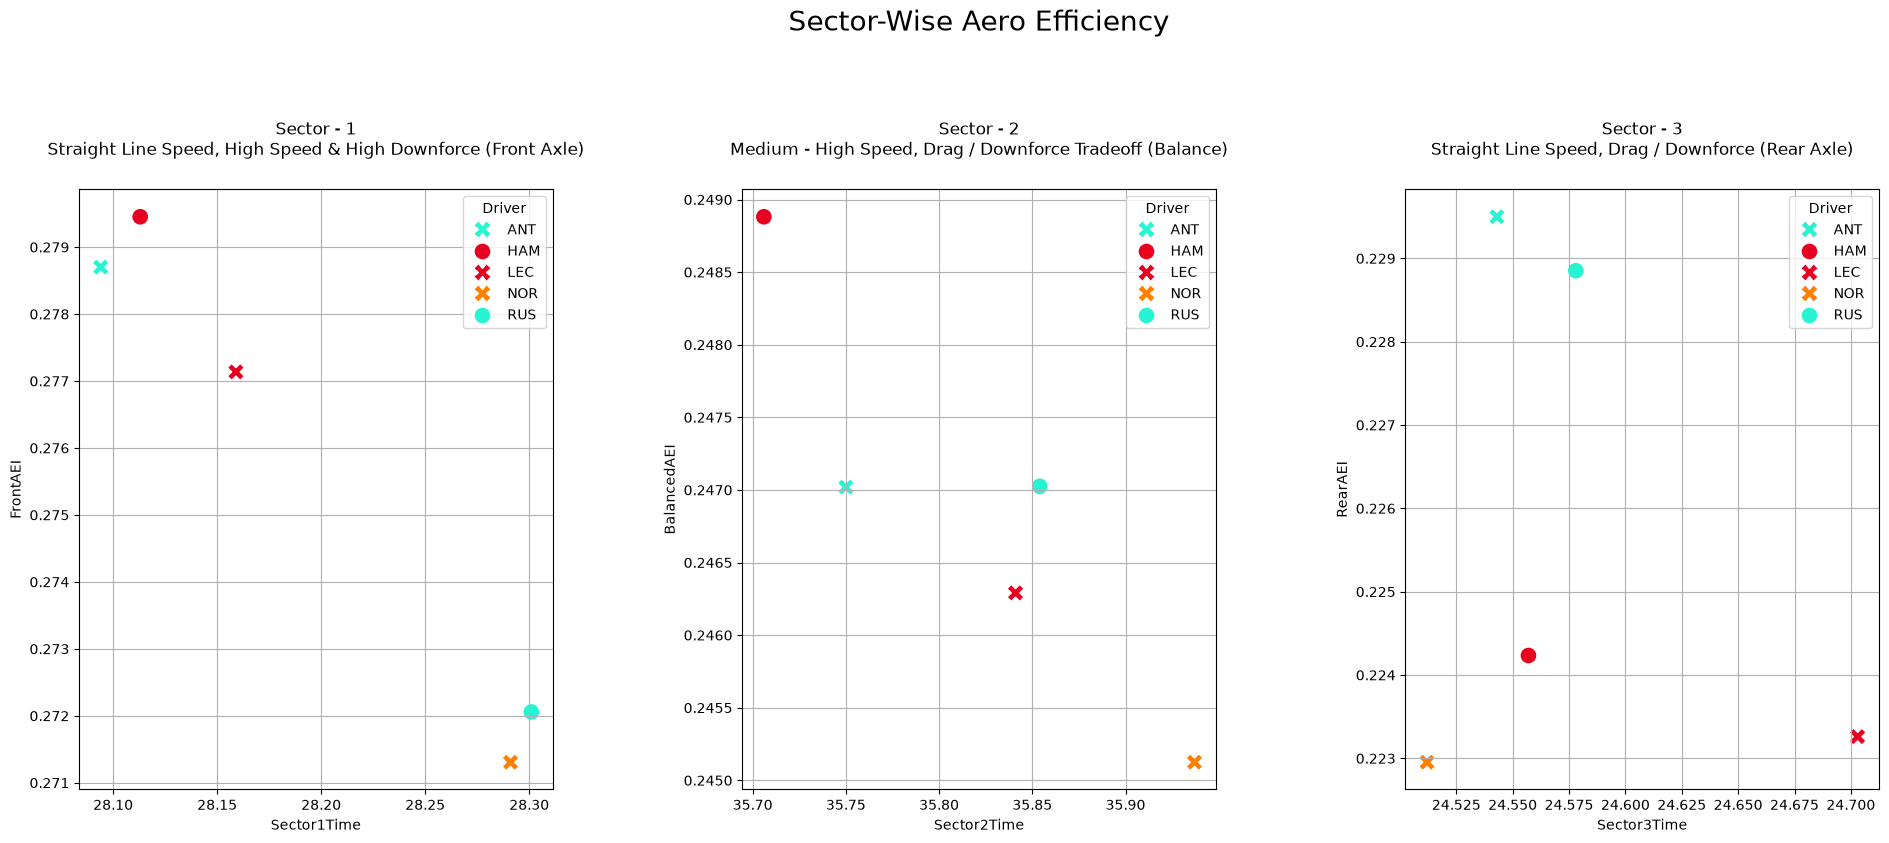

In [12]:
aei_fig = data_vis.create_scatter_plots(
    nrows=1,
    ncols=3,
    figsize=(30, 10),
    data=fastest_quali_laps,
    hue="Driver",
    style="Driver",
    size=150,
    plot_kind="aero"
)

aei_fig.suptitle(
    "Sector-Wise Aero Efficiency",
    fontsize=20
)
plt.subplots_adjust(left=0.2, right=0.8, bottom=0.2, top=0.80, wspace=0.4)
plt.show()

**Important**
- As seen the scatter plots above, the way I have designed the features for Aero Efficiency is dependent on two factors which are:
    - Driver Sector Speed as a ratio of their Top Speed.
    - Driver Sector Time as a ratio of the Purple Sector Time.
- Thus, the above graphs are evidently showcasing this tradeoff as engineered in the setup of teams and driving styles.

**Notable Points**
- `Antonelli` has the best time in Sector-1 which he managed to achieve by almost maximising the best correlation for the sector ie. a good balance of Drag and Downforce. While **Hamilton** was a close 2nd with minor difference however, the interesting this is both have -ve KE retention for the sector. Thus, they deployed heavily in the sector.
- `Hamilton` was by far the best in Sector-2 which he managed by consistently staying on the throttle as in the GP Tempo telemetry trace. This also meant that he kept experiencing clipping but he mitigated that with reduced brake usage to retain speed.
- `Norris` was the fastest in Sector-3 despite low speed exit speed through Chapel (end of sector-2), which could only mean one thing, clipping through the high-speed section. Thus, he was still able to make up time with the strength of the MGU-K which is evident as he also has the highest speed through the Speed Trap at the end of the Hangar Straight.

### KE and Power Plots

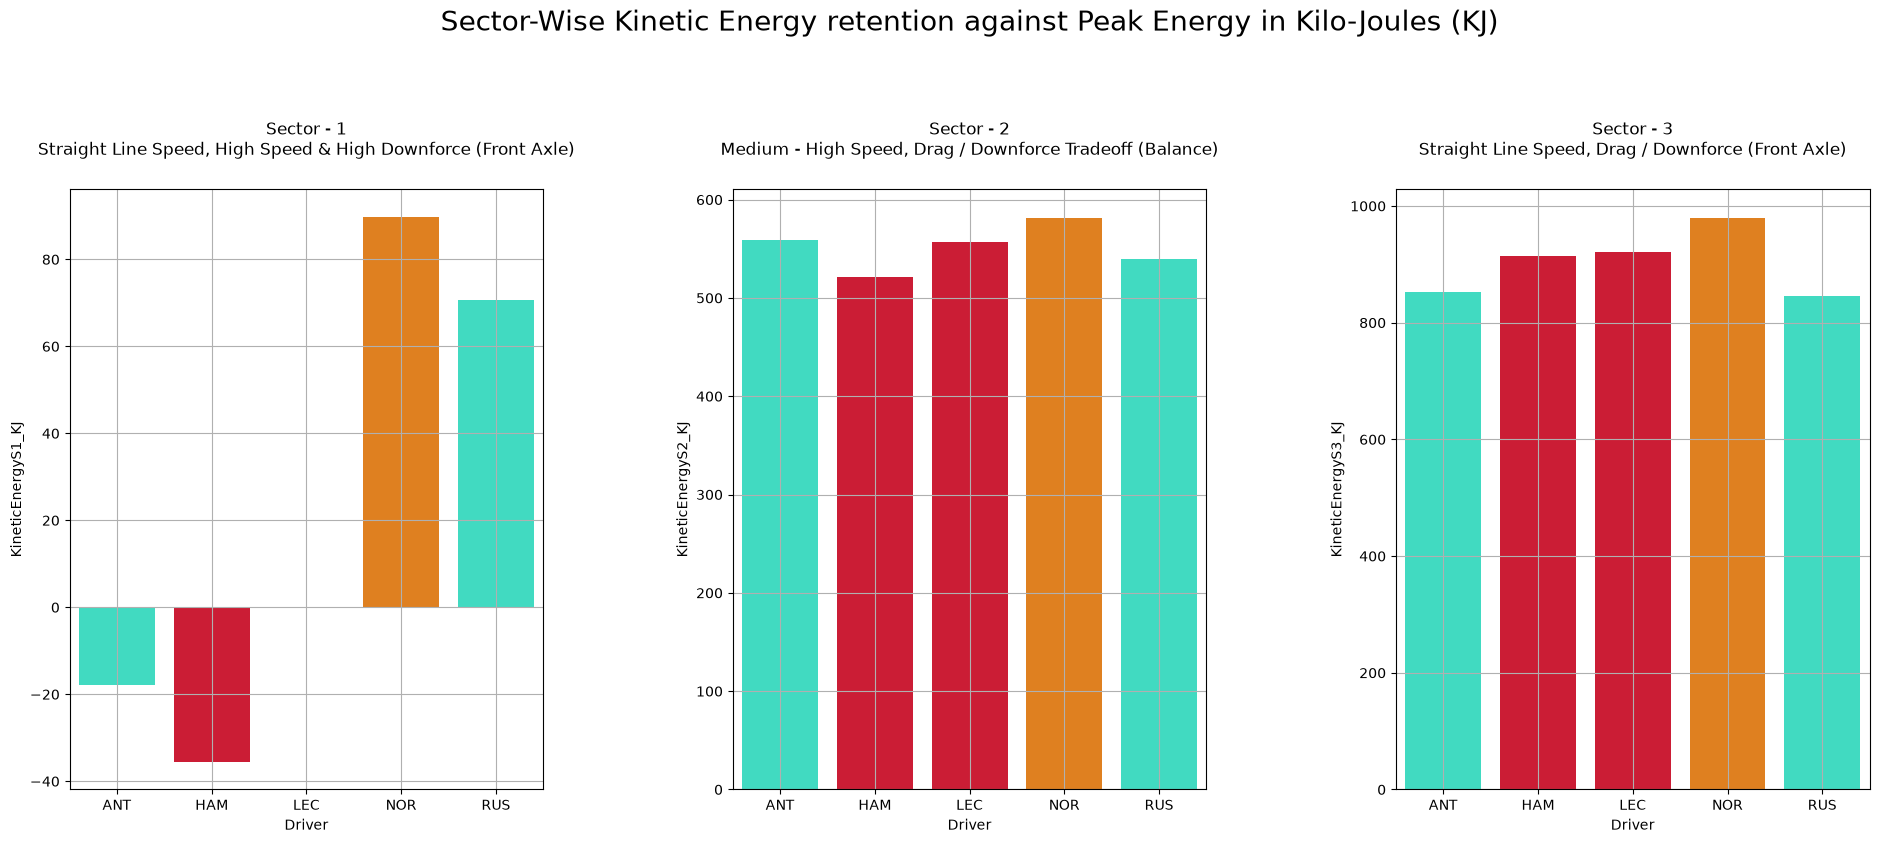

In [13]:
kep_fig = data_vis.create_bar_plots(
    nrows=1, 
    ncols=3,
    figsize=(30, 10),
    data=fastest_quali_laps,
    hue="Driver",
    plot_kind="ke"
)

kep_fig.suptitle(
    "Sector-Wise Kinetic Energy retention against Peak Energy in Kilo-Joules (KJ)",
    fontsize=20
)
plt.subplots_adjust(left=0.2, right=0.8, bottom=0.2, top=0.80, wspace=0.4)
plt.show()

**Important**
- As seen in the bar plots above there is significant difference in trends that needs explanation. The way I have engineered the features for KE retentions suggests the lower KE retention the better (however, this doesn't suggest -ve values to be better).
- This inverse relationship (lower is better) is due to features representing the Delta in KE for each of the sectors wrt each of the drivers respective top speeds. Thus, for every sector the driver maintains lower delta in KE the more time he gains as the PU doesn't need to do extra work to gain speed and remains close to the top band of power.
- However, we can see there a few -ve bars in the plot above. This in indicative of Hamilton and Antonelli having a much higher sector speed (V1) than the absolute top speed at the speed trap (V2). On the otherhand Leclerc matches his top speed and hence has no bar (as the delta is 0). 
- This further explains the usage of the PU for the respective cars as Silverstone is a High Energy track with long straights and High Speed corners. Thus, the current regulations mean energy efficiency is vital and there are little to no places to efficiently harvest for consistent high power retention.
- All of this is verified below in the ERS clipping plot which for Silverstone, the ERS clip has been taken as the ratio of speed at the end of Sector - 2 and the top speed at the Speed Trap in the middle of Sector - 3. We can see that both Verstappen and Hamilton have $ers\_clipping < 1.0$ ie they are having a higher Speed through Sector - 1 than the Speed Trap.

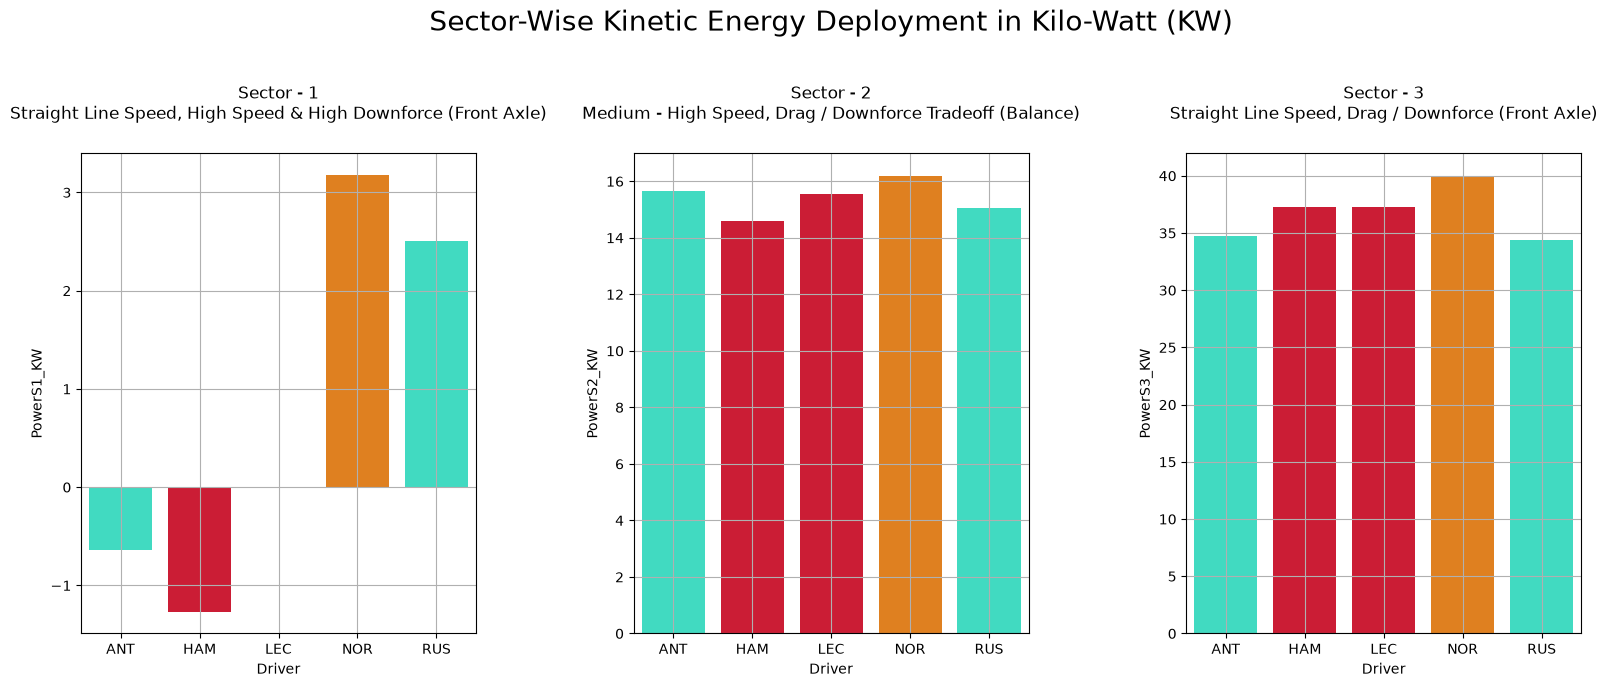

In [14]:
power_fig = data_vis.create_bar_plots(
    nrows=1,
    ncols=3,
    figsize=(25, 8),
    data=fastest_quali_laps,
    hue="Driver",
    plot_kind="power"
)

power_fig.suptitle(
    "Sector-Wise Kinetic Energy Deployment in Kilo-Watt (KW)",
    fontsize=20
)
plt.subplots_adjust(left=0.2, right=0.8, bottom=0.2, top=0.80, wspace=0.4)
plt.show()

### ICE Strength

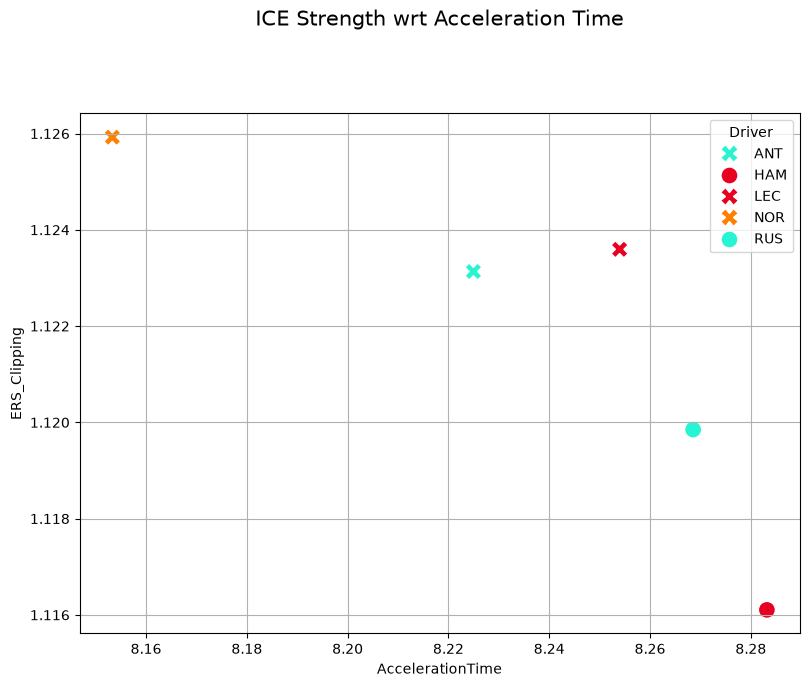

In [15]:
ice_fig = data_vis.create_scatter_plots(
    nrows=1,
    ncols=1,
    figsize=(12, 8),
    data=fastest_quali_laps,
    hue="Driver",
    style="Driver",
    size=150,
    plot_kind="ers_clip"
)

ice_fig.suptitle("ICE Strength wrt Acceleration Time", fontsize=15)
plt.subplots_adjust(left=0.2, right=0.8, bottom=0.2, top=0.85)
plt.show()

In [16]:
# Saving the final frame
fastest_quali_laps.to_csv(f1_data_path / "sprint_quali_performance_britain.csv", index=False)

## Cheers 🙃!
Now time to put the data into work in the race debrief.